# Wrist Temperature Cluster Prediction — Machine Learning Models

This notebook trains and evaluates Random Forest and Neural Network models to predict wrist skin temperature cluster membership from sleep and physiological features collected by the Fitbit Sense wearable.

## Objective

Predict whether an observation belongs to the high or low wrist temperature cluster using raw features including HRV, respiratory rate, sleep stages, and oxygen saturation. Temperature-derived features are excluded.

## Models

- **Random Forest** — trained on raw features
- **Neural Network (MLP)** — two hidden layers (32, 16 units), trained on features standardized within each training fold

## Evaluation

- Participant-level five-fold cross-validation
- Accuracy, precision, recall, F1, and ROC AUC
- Out-of-fold ROC curves and confusion matrices

## Interpretability

- SHAP analysis of Random Forest predictions
- Feature importance bar plot and SHAP beeswarm plot

## Key Finding

The Random Forest showed modest predictive ability across held-out participants (out-of-fold ROC AUC = 0.625). The Neural Network performed poorly (out-of-fold ROC AUC = 0.478). These results do not establish that the measured sleep variables cause the two wrist temperature profiles.


RANDOM FOREST — RESULTS BY FOLD
 fold  accuracy  precision  recall    f1  roc_auc
    1     0.580      0.636   0.519 0.571    0.594
    2     0.605      0.800   0.222 0.348    0.631
    3     0.729      0.385   0.312 0.345    0.666
    4     0.654      0.727   0.348 0.471    0.675
    5     0.647      0.769   0.400 0.526    0.615

NEURAL NETWORK — RESULTS BY FOLD
 fold  accuracy  precision  recall    f1  roc_auc
    1     0.620      0.900   0.333 0.486    0.670
    2     0.447      0.000   0.000 0.000    0.436
    3     0.414      0.245   0.750 0.369    0.527
    4     0.538      0.478   0.478 0.478    0.498
    5     0.569      1.000   0.120 0.214    0.660

FINAL 5-FOLD CROSS-VALIDATION PERFORMANCE

RANDOM FOREST
ACCURACY  : 0.643 ± 0.057
PRECISION : 0.663 ± 0.168
RECALL    : 0.360 ± 0.110
F1        : 0.452 ± 0.103
ROC_AUC   : 0.636 ± 0.034

NEURAL NETWORK
ACCURACY  : 0.518 ± 0.085
PRECISION : 0.525 ± 0.425
RECALL    : 0.336 ± 0.296
F1        : 0.310 ± 0.205
ROC_AUC   : 0.558 ± 0.103

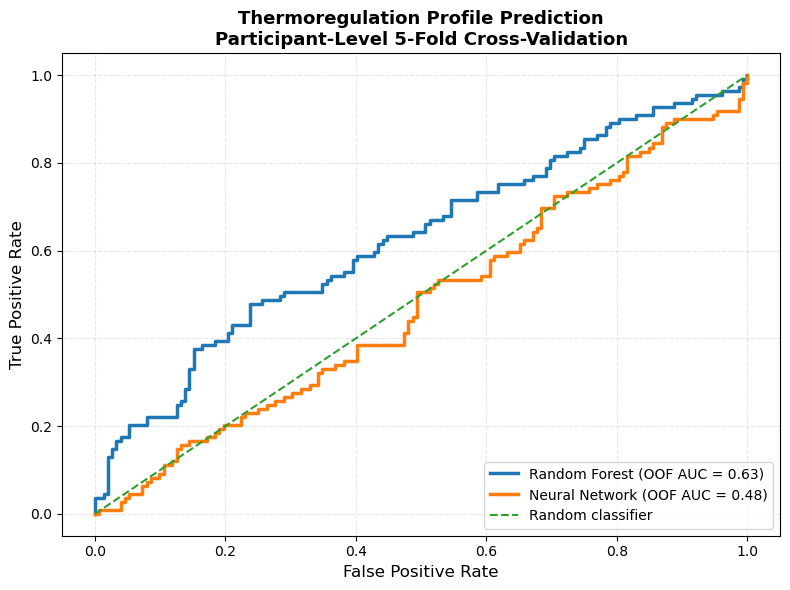

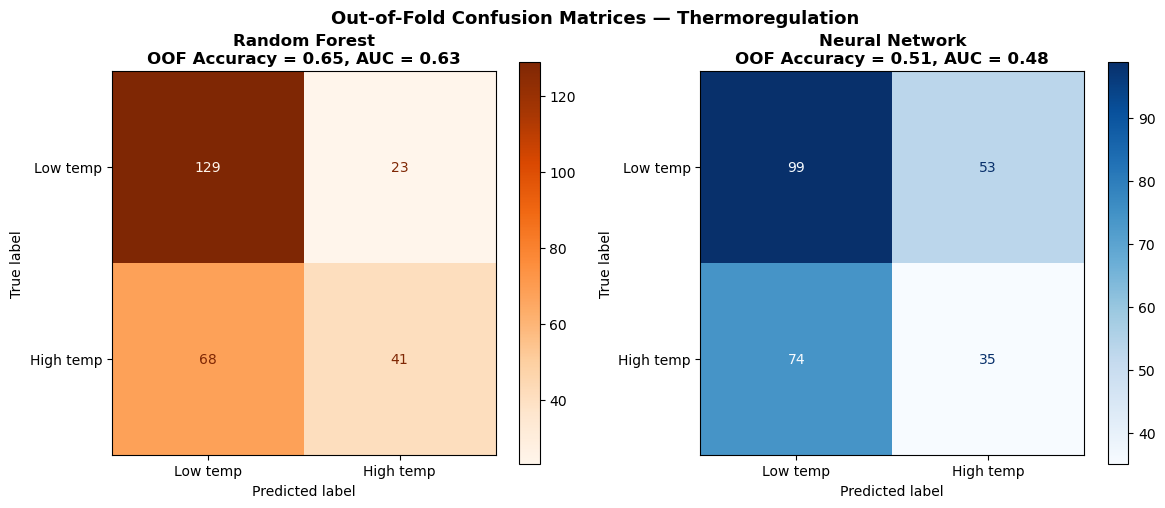


CROSS-VALIDATED RANDOM FOREST FEATURE IMPORTANCE
                        feature   mean    std
                          rmssd 0.1671 0.0245
              restlessness_mean 0.1169 0.0208
                        nrem_hr 0.0761 0.0085
   rem_sleep_standard_deviation 0.0732 0.0102
             resting_heart_rate 0.0698 0.0135
      full_sleep_breathing_rate 0.0648 0.0084
sleep_average_oxygen_saturation 0.0600 0.0057
                 minutes_asleep 0.0583 0.0068
       rem_sleep_breathing_rate 0.0544 0.0047
      deep_sleep_breathing_rate 0.0536 0.0058
                   deep_minutes 0.0485 0.0072
                    rem_minutes 0.0421 0.0049
  full_sleep_standard_deviation 0.0401 0.0038
                  overall_score 0.0391 0.0014
  deep_sleep_standard_deviation 0.0360 0.0047


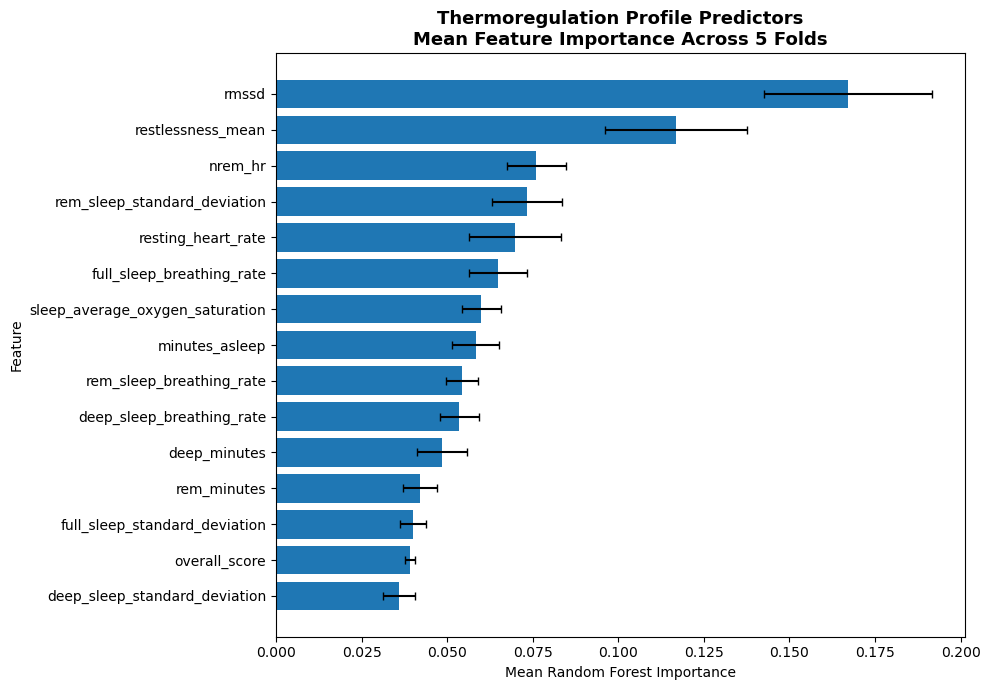

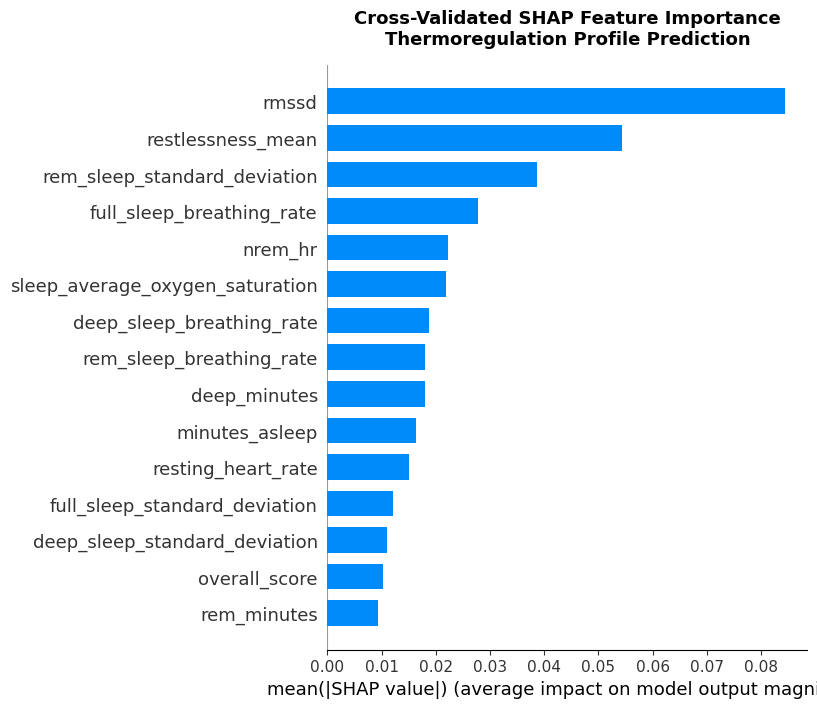

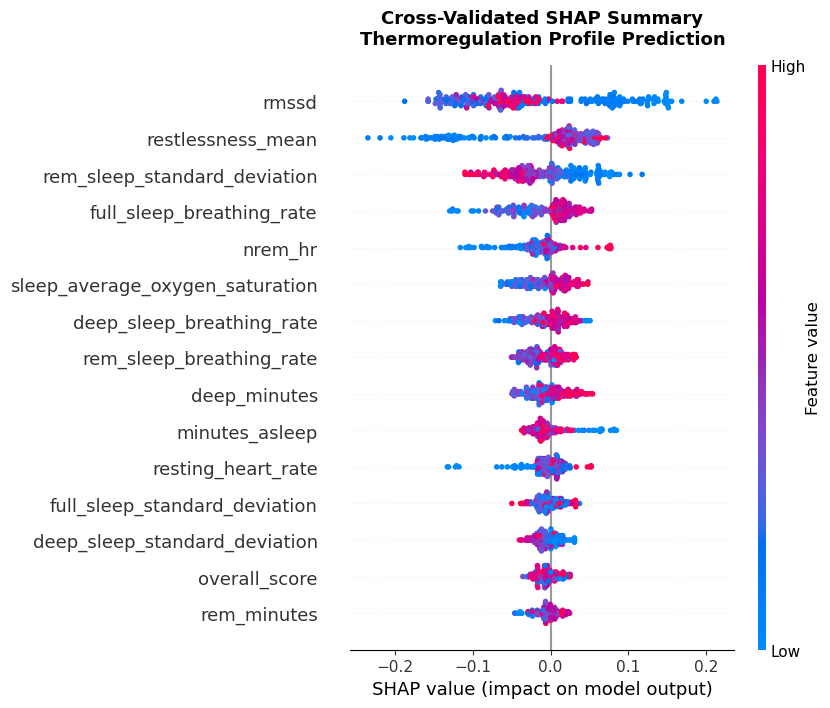

In [5]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay
)


# CONFIGURATION

RANDOM_STATE = 42
N_SPLITS = 5

np.random.seed(RANDOM_STATE)

DATA_PATH = "data/wrist_temp_model_no_temperature.xlsx"
SHEET_NAME = "Model_Data_No_Temperature"

TARGET_COL = "aligned_cluster_label"
ID_COL = "participant_id"

FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)


# LOAD DATA

df = pd.read_excel(
    DATA_PATH,
    sheet_name=SHEET_NAME
)


# FEATURES

FEATURE_COLS = [
    # Sleep architecture
    "rem_minutes",
    "deep_minutes",
    "overall_score",
    "restlessness_mean",
    "minutes_asleep",

    # Respiratory physiology
    "deep_sleep_breathing_rate",
    "rem_sleep_breathing_rate",
    "full_sleep_breathing_rate",
    "full_sleep_standard_deviation",
    "deep_sleep_standard_deviation",
    "rem_sleep_standard_deviation",

    # Oxygen saturation
    "sleep_average_oxygen_saturation",

    # Cardiovascular physiology
    "rmssd",
    "nrem_hr",
    "resting_heart_rate"
]


# DATA VALIDATION

required_columns = FEATURE_COLS + [
    TARGET_COL,
    ID_COL,
    "study_day",
    "date"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns:\n"
        + "\n".join(missing_columns)
    )


# No precomputed normalized features
norm_features = [
    feature
    for feature in FEATURE_COLS
    if feature.endswith("_norm")
]

assert len(norm_features) == 0, (
    "ERROR: Precomputed *_norm features detected."
)


# No direct/derived temperature predictors
FORBIDDEN_TEMPERATURE_FEATURES = [
    "nightly_temperature",
    "nightly_temperature_norm",
    "baseline_relative_nightly_standard_deviation",
    "baseline_relative_nightly_standard_deviation_norm"
]

for feature in FORBIDDEN_TEMPERATURE_FEATURES:
    if feature in FEATURE_COLS:
        raise ValueError(
            f"Temperature-derived predictor detected: {feature}"
        )


# Check duplicated participant-days
duplicate_count = df.duplicated(
    subset=[
        ID_COL,
        "study_day",
        "date"
    ],
    keep=False
).sum()

if duplicate_count > 0:
    raise ValueError(
        "Duplicated participant-day observations remain."
    )


# Check missing values
missing = df[
    FEATURE_COLS + [TARGET_COL, ID_COL]
].isna().sum()

missing = missing[missing > 0]

if len(missing) > 0:
    raise ValueError(
        "Missing values must be handled before cross-validation.\n"
        + missing.to_string()
    )


# PREPARE DATA

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].astype(int).copy()
groups = df[ID_COL].copy()


# PARTICIPANT-LEVEL STRATIFIED 5-FOLD CV

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# STORAGE

rf_fold_results = []
nn_fold_results = []

fold_assignments = []
rf_importances = []

oof_rf_pred = np.zeros(len(df), dtype=int)
oof_rf_proba = np.zeros(len(df), dtype=float)

oof_nn_pred = np.zeros(len(df), dtype=int)
oof_nn_proba = np.zeros(len(df), dtype=float)


# CROSS-VALIDATION

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X, y, groups=groups),
    start=1
):

   
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    groups_train = groups.iloc[train_idx]
    groups_test = groups.iloc[test_idx]


    
    train_participants = set(groups_train.unique())
    test_participants = set(groups_test.unique())

    overlap = train_participants.intersection(
        test_participants
    )

    if len(overlap) > 0:
        raise ValueError(
            f"Participant leakage detected in fold {fold}."
        )


    if y_train.nunique() < 2:
        raise ValueError(
            f"Fold {fold} training set contains only one class."
        )

    if y_test.nunique() < 2:
        raise ValueError(
            f"Fold {fold} test set contains only one class."
        )


   

    for idx in test_idx:

        fold_assignments.append({
            "row_index": idx,
            "participant_id": df.iloc[idx][ID_COL],
            "study_day": df.iloc[idx]["study_day"],
            "date": df.iloc[idx]["date"],
            "temperature_cluster": y.iloc[idx],
            "fold": fold
        })


    

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )


    # RANDOM FOREST

    rf = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE + fold,
        n_jobs=-1
    )

    rf.fit(
        X_train,
        y_train
    )

    rf_pred = rf.predict(
        X_test
    )

    class1_index_rf = list(
        rf.classes_
    ).index(1)

    rf_proba = rf.predict_proba(
        X_test
    )[:, class1_index_rf]


    oof_rf_pred[test_idx] = rf_pred
    oof_rf_proba[test_idx] = rf_proba


    rf_accuracy = accuracy_score(
        y_test,
        rf_pred
    )

    rf_precision = precision_score(
        y_test,
        rf_pred,
        zero_division=0
    )

    rf_recall = recall_score(
        y_test,
        rf_pred,
        zero_division=0
    )

    rf_f1 = f1_score(
        y_test,
        rf_pred,
        zero_division=0
    )

    rf_auc = roc_auc_score(
        y_test,
        rf_proba
    )


    rf_fold_results.append({
        "fold": fold,
        "accuracy": rf_accuracy,
        "precision": rf_precision,
        "recall": rf_recall,
        "f1": rf_f1,
        "roc_auc": rf_auc,
        "train_observations": len(train_idx),
        "test_observations": len(test_idx),
        "train_participants": len(train_participants),
        "test_participants": len(test_participants)
    })


    fold_importance = pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance": rf.feature_importances_,
        "fold": fold
    })

    rf_importances.append(
        fold_importance
    )


    # NEURAL NETWORK

    nn = MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.20,
        random_state=RANDOM_STATE + fold
    )

    nn.fit(
        X_train_scaled,
        y_train
    )

    nn_pred = nn.predict(
        X_test_scaled
    )

    class1_index_nn = list(
        nn.classes_
    ).index(1)

    nn_proba = nn.predict_proba(
        X_test_scaled
    )[:, class1_index_nn]


    oof_nn_pred[test_idx] = nn_pred
    oof_nn_proba[test_idx] = nn_proba


    nn_accuracy = accuracy_score(
        y_test,
        nn_pred
    )

    nn_precision = precision_score(
        y_test,
        nn_pred,
        zero_division=0
    )

    nn_recall = recall_score(
        y_test,
        nn_pred,
        zero_division=0
    )

    nn_f1 = f1_score(
        y_test,
        nn_pred,
        zero_division=0
    )

    nn_auc = roc_auc_score(
        y_test,
        nn_proba
    )


    nn_fold_results.append({
        "fold": fold,
        "accuracy": nn_accuracy,
        "precision": nn_precision,
        "recall": nn_recall,
        "f1": nn_f1,
        "roc_auc": nn_auc,
        "train_observations": len(train_idx),
        "test_observations": len(test_idx),
        "train_participants": len(train_participants),
        "test_participants": len(test_participants)
    })


# RESULTS DATAFRAMES

rf_results = pd.DataFrame(
    rf_fold_results
)

nn_results = pd.DataFrame(
    nn_fold_results
)


# RESULTS BY FOLD

print("\n" + "=" * 70)
print("RANDOM FOREST — RESULTS BY FOLD")
print("=" * 70)

print(
    rf_results[
        [
            "fold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    ]
    .round(3)
    .to_string(index=False)
)


print("\n" + "=" * 70)
print("NEURAL NETWORK — RESULTS BY FOLD")
print("=" * 70)

print(
    nn_results[
        [
            "fold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    ]
    .round(3)
    .to_string(index=False)
)


# MEAN ± STANDARD DEVIATION

METRICS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]


def summarize_cv(results):

    summary = {}

    for metric in METRICS:

        summary[
            f"{metric}_mean"
        ] = results[metric].mean()

        summary[
            f"{metric}_sd"
        ] = results[metric].std(
            ddof=1
        )

    return summary


rf_summary = summarize_cv(
    rf_results
)

nn_summary = summarize_cv(
    nn_results
)


# FINAL CV PERFORMANCE

print("\n" + "=" * 70)
print("FINAL 5-FOLD CROSS-VALIDATION PERFORMANCE")
print("=" * 70)


print("\nRANDOM FOREST")

for metric in METRICS:

    print(
        f"{metric.upper():10s}: "
        f"{rf_summary[f'{metric}_mean']:.3f} "
        f"± "
        f"{rf_summary[f'{metric}_sd']:.3f}"
    )


print("\nNEURAL NETWORK")

for metric in METRICS:

    print(
        f"{metric.upper():10s}: "
        f"{nn_summary[f'{metric}_mean']:.3f} "
        f"± "
        f"{nn_summary[f'{metric}_sd']:.3f}"
    )


# OUT-OF-FOLD PERFORMANCE

rf_oof_accuracy = accuracy_score(
    y,
    oof_rf_pred
)

rf_oof_precision = precision_score(
    y,
    oof_rf_pred,
    zero_division=0
)

rf_oof_recall = recall_score(
    y,
    oof_rf_pred,
    zero_division=0
)

rf_oof_f1 = f1_score(
    y,
    oof_rf_pred,
    zero_division=0
)

rf_oof_auc = roc_auc_score(
    y,
    oof_rf_proba
)


nn_oof_accuracy = accuracy_score(
    y,
    oof_nn_pred
)

nn_oof_precision = precision_score(
    y,
    oof_nn_pred,
    zero_division=0
)

nn_oof_recall = recall_score(
    y,
    oof_nn_pred,
    zero_division=0
)

nn_oof_f1 = f1_score(
    y,
    oof_nn_pred,
    zero_division=0
)

nn_oof_auc = roc_auc_score(
    y,
    oof_nn_proba
)


print("\n" + "=" * 70)
print("OUT-OF-FOLD PERFORMANCE")
print("=" * 70)


print("\nRandom Forest")

print(f"Accuracy:  {rf_oof_accuracy:.3f}")
print(f"Precision: {rf_oof_precision:.3f}")
print(f"Recall:    {rf_oof_recall:.3f}")
print(f"F1:        {rf_oof_f1:.3f}")
print(f"ROC-AUC:   {rf_oof_auc:.3f}")


print("\nNeural Network")

print(f"Accuracy:  {nn_oof_accuracy:.3f}")
print(f"Precision: {nn_oof_precision:.3f}")
print(f"Recall:    {nn_oof_recall:.3f}")
print(f"F1:        {nn_oof_f1:.3f}")
print(f"ROC-AUC:   {nn_oof_auc:.3f}")


# CLASSIFICATION REPORTS

print("\n" + "=" * 70)
print("RANDOM FOREST — OOF CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y,
        oof_rf_pred,
        target_names=[
            "Low temperature cluster",
            "High temperature cluster"
        ],
        digits=3
    )
)


print("\n" + "=" * 70)
print("NEURAL NETWORK — OOF CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y,
        oof_nn_pred,
        target_names=[
            "Low temperature cluster",
            "High temperature cluster"
        ],
        digits=3
    )
)


# FIGURE 1 : ROC CURVES

fpr_rf, tpr_rf, _ = roc_curve(
    y,
    oof_rf_proba
)

fpr_nn, tpr_nn, _ = roc_curve(
    y,
    oof_nn_proba
)


plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2.5,
    label=(
        f"Random Forest "
        f"(OOF AUC = {rf_oof_auc:.2f})"
    )
)

plt.plot(
    fpr_nn,
    tpr_nn,
    linewidth=2.5,
    label=(
        f"Neural Network "
        f"(OOF AUC = {nn_oof_auc:.2f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "Thermoregulation Profile Prediction\n"
    "Participant-Level 5-Fold Cross-Validation",
    fontsize=13,
    fontweight="bold"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()


roc_path = os.path.join(
    FIGURE_DIR,
    "thermoregulation_cv_roc_curve.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# FIGURE 2 : CONFUSION MATRICES

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


ConfusionMatrixDisplay.from_predictions(
    y,
    oof_rf_pred,
    display_labels=[
        "Low temp",
        "High temp"
    ],
    cmap="Oranges",
    ax=axes[0]
)

axes[0].set_title(
    "Random Forest\n"
    f"OOF Accuracy = {rf_oof_accuracy:.2f}, "
    f"AUC = {rf_oof_auc:.2f}",
    fontweight="bold"
)

axes[0].grid(False)


ConfusionMatrixDisplay.from_predictions(
    y,
    oof_nn_pred,
    display_labels=[
        "Low temp",
        "High temp"
    ],
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title(
    "Neural Network\n"
    f"OOF Accuracy = {nn_oof_accuracy:.2f}, "
    f"AUC = {nn_oof_auc:.2f}",
    fontweight="bold"
)

axes[1].grid(False)


plt.suptitle(
    "Out-of-Fold Confusion Matrices — Thermoregulation",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()


cm_path = os.path.join(
    FIGURE_DIR,
    "thermoregulation_cv_confusion_matrices.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# RF FEATURE IMPORTANCE

all_importances = pd.concat(
    rf_importances,
    ignore_index=True
)

importance_summary = (
    all_importances
    .groupby("feature")["importance"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values(
        "mean",
        ascending=False
    )
)


print("\n" + "=" * 70)
print("CROSS-VALIDATED RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

print(
    importance_summary
    .round(4)
    .to_string(index=False)
)


# FIGURE 3 : RF FEATURE IMPORTANCE

plot_importance = (
    importance_summary
    .head(15)
    .sort_values(
        "mean",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 7)
)

plt.barh(
    plot_importance["feature"],
    plot_importance["mean"],
    xerr=plot_importance["std"],
    capsize=3
)

plt.xlabel(
    "Mean Random Forest Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Thermoregulation Profile Predictors\n"
    "Mean Feature Importance Across 5 Folds",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()


importance_path = os.path.join(
    FIGURE_DIR,
    "thermoregulation_cv_rf_feature_importance.png"
)

plt.savefig(
    importance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# CROSS-VALIDATED OUT-OF-FOLD SHAP

shap_parts = []
X_shap_parts = []


for fold, (train_idx, test_idx) in enumerate(
    cv.split(X, y, groups=groups),
    start=1
):

    X_train = X.iloc[
        train_idx
    ].copy()

    X_test = X.iloc[
        test_idx
    ].copy()

    y_train = y.iloc[
        train_idx
    ].copy()


    rf_shap = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE + fold,
        n_jobs=-1
    )

    rf_shap.fit(
        X_train,
        y_train
    )


    explainer = shap.TreeExplainer(
        rf_shap
    )

    shap_values = explainer.shap_values(
        X_test
    )


    if (
        isinstance(shap_values, np.ndarray)
        and
        shap_values.ndim == 3
    ):

        shap_class1 = shap_values[:, :, 1]

    elif isinstance(
        shap_values,
        list
    ):

        shap_class1 = shap_values[1]

    else:

        shap_class1 = shap_values


    shap_parts.append(
        shap_class1
    )

    X_shap_parts.append(
        X_test
    )


shap_oof = np.vstack(
    shap_parts
)

X_shap_oof = pd.concat(
    X_shap_parts,
    axis=0
).reset_index(
    drop=True
)


# FIGURE 4 : SHAP BAR PLOT

plt.figure(
    figsize=(14, 8)
)

shap.summary_plot(
    shap_oof,
    X_shap_oof,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "Cross-Validated SHAP Feature Importance\n"
    "Thermoregulation Profile Prediction",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.subplots_adjust(
    left=0.35,
    right=0.95,
    top=0.88,
    bottom=0.10
)


shap_bar_path = os.path.join(
    FIGURE_DIR,
    "thermoregulation_cv_shap_importance.png"
)

plt.savefig(
    shap_bar_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# FIGURE 5 : SHAP BEESWARM

plt.figure(
    figsize=(16, 10)
)

shap.summary_plot(
    shap_oof,
    X_shap_oof,
    max_display=15,
    show=False
)

plt.title(
    "Cross-Validated SHAP Summary\n"
    "Thermoregulation Profile Prediction",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.subplots_adjust(
    left=0.35,
    right=0.95,
    top=0.88,
    bottom=0.10
)


shap_beeswarm_path = os.path.join(
    FIGURE_DIR,
    "thermoregulation_cv_shap_beeswarm.png"
)

plt.savefig(
    shap_beeswarm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# SAVE RESULTS

rf_results.to_csv(
    os.path.join(
        FIGURE_DIR,
        "thermoregulation_cv_rf_fold_results.csv"
    ),
    index=False
)


nn_results.to_csv(
    os.path.join(
        FIGURE_DIR,
        "thermoregulation_cv_nn_fold_results.csv"
    ),
    index=False
)


importance_summary.to_csv(
    os.path.join(
        FIGURE_DIR,
        "thermoregulation_cv_rf_feature_importance.csv"
    ),
    index=False
)


fold_assignments_df = pd.DataFrame(
    fold_assignments
)

fold_assignments_df.to_csv(
    os.path.join(
        FIGURE_DIR,
        "thermoregulation_cv_fold_assignments.csv"
    ),
    index=False
)


oof_predictions = df[
    [
        ID_COL,
        "study_day",
        "date",
        TARGET_COL
    ]
].copy()

oof_predictions[
    "rf_prediction"
] = oof_rf_pred

oof_predictions[
    "rf_probability"
] = oof_rf_proba

oof_predictions[
    "nn_prediction"
] = oof_nn_pred

oof_predictions[
    "nn_probability"
] = oof_nn_proba


oof_predictions.to_csv(
    os.path.join(
        FIGURE_DIR,
        "thermoregulation_cv_oof_predictions.csv"
    ),
    index=False
)


# FINAL SUMMARY TABLE

summary_table = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Neural Network"
    ],

    "Accuracy_mean": [
        rf_summary["accuracy_mean"],
        nn_summary["accuracy_mean"]
    ],

    "Accuracy_SD": [
        rf_summary["accuracy_sd"],
        nn_summary["accuracy_sd"]
    ],

    "Precision_mean": [
        rf_summary["precision_mean"],
        nn_summary["precision_mean"]
    ],

    "Precision_SD": [
        rf_summary["precision_sd"],
        nn_summary["precision_sd"]
    ],

    "Recall_mean": [
        rf_summary["recall_mean"],
        nn_summary["recall_mean"]
    ],

    "Recall_SD": [
        rf_summary["recall_sd"],
        nn_summary["recall_sd"]
    ],

    "F1_mean": [
        rf_summary["f1_mean"],
        nn_summary["f1_mean"]
    ],

    "F1_SD": [
        rf_summary["f1_sd"],
        nn_summary["f1_sd"]
    ],

    "ROC_AUC_mean": [
        rf_summary["roc_auc_mean"],
        nn_summary["roc_auc_mean"]
    ],

    "ROC_AUC_SD": [
        rf_summary["roc_auc_sd"],
        nn_summary["roc_auc_sd"]
    ],

    "OOF_Accuracy": [
        rf_oof_accuracy,
        nn_oof_accuracy
    ],

    "OOF_F1": [
        rf_oof_f1,
        nn_oof_f1
    ],

    "OOF_ROC_AUC": [
        rf_oof_auc,
        nn_oof_auc
    ]

})


summary_table.to_csv(
    os.path.join(
        FIGURE_DIR,
        "thermoregulation_cv_summary.csv"
    ),
    index=False
)